In [78]:
import json
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [79]:
load_dotenv()

True

In [80]:
model = ChatOpenAI(model="gpt-4o-mini")

In [81]:
class EvaluationSchema(BaseModel):
    score: int = Field(description="Score between 1 and 10")
    feedback: str = Field(description="Detailed feedback on the essay")

In [82]:
structured_output = model.with_structured_output(EvaluationSchema)

In [83]:
class EssayState(TypedDict):
    essay: str
    grammar_score: int
    grammar_feedback: str
    clarity_score: int
    clarity_feedback: str
    overall_score: int
    overall_feedback: str

In [84]:
def evaluate_essay_grammar(state: EssayState) -> EssayState:
    essay = state["essay"]
    grammatical_prompt_template = f"""
    You are an expert English grammar evaluator. Analyze the provided essay {essay} and evaluate its grammatical quality based on:

    1. **Sentence Structure** (clarity, completeness, variety)
    2. **Punctuation** (commas, periods, apostrophes, etc.)
    3. **Spelling** (correctness of all words)
    4. **Verb Tense Consistency** (proper tense usage throughout)
    5. **Subject-Verb Agreement** (singular/plural matching)
    6. **Word Choice & Collocations** (appropriate vocabulary usage)
    7. **Article Usage** (a/an/the correctness)
    8. **Preposition Usage** (in/on/at/of/for etc.)

    Scoring Criteria:
    - Score 1-3: Major grammatical errors in every sentence, text is barely comprehensible
    - Score 4-5: Frequent errors that impede understanding
    - Score 6-7: Some errors but overall meaning is clear
    - Score 8-9: Minor errors only, very good grammar
    - Score 10: Perfect grammar, native-level proficiency

    Be specific in your feedback. Point out actual errors with corrections when possible.
"""
    
    response =  structured_output.invoke(grammatical_prompt_template)
    return {
        "grammar_score": response.score,
        "grammar_feedback": response.feedback
    }



In [85]:
def evaluate_clarity_of_thought(state: EssayState) -> EssayState:
    essay = state["essay"]
    clarity_prompt_template = f"""
    You are an expert evaluator of writing clarity. Analyze the provided essay {essay} and evaluate its clarity based on:

    1. **Logical Flow** (coherence and organization of ideas)
    2. **Conciseness** (avoidance of unnecessary words or repetition)
    3. **Precision** (use of specific and accurate language)
    4. **Ambiguity** (presence of unclear or vague statements)
    5. **Focus** (staying on topic without digressions)

    Scoring Criteria:
    - Score 1-3: Very unclear, difficult to understand the main points
    - Score 4-5: Somewhat unclear, ideas are not well connected
    - Score 6-7: Generally clear but with some confusing sections
    - Score 8-9: Clear and well-organized with minor issues
    - Score 10: Exceptionally clear, concise, and well-structured

    Provide specific feedback on how to improve the clarity of the essay.
"""
    
    response =  structured_output.invoke(clarity_prompt_template)
    return {
        "clarity_feedback": response.feedback,
        "clarity_score": response.score,
    }

In [86]:
def final_summary(state: EssayState) -> EssayState:
    grammar_score = state["grammar_score"]
    grammar_feedback = state["grammar_feedback"]
    clarity_score = state["clarity_score"]
    clarity_feedback = state["clarity_feedback"]
    
    overall_prompt_template = f"""
    You are an expert essay evaluator. Based on the following feedback and scores, provide an overall evaluation of the essay:

    Grammar Evaluation:
    - Score: {grammar_score}
    - Feedback: {grammar_feedback}

    Clarity Evaluation:
    - Score: {clarity_score}
    - Feedback: {clarity_feedback}

    Overall Scoring Criteria:
    - Score 1-3: Poor essay with significant issues in both grammar and clarity
    - Score 4-5: Below average essay with noticeable problems
    - Score 6-7: Average essay with some strengths and weaknesses
    - Score 8-9: Good essay with minor issues
    - Score 10: Excellent essay with strong grammar and clarity

    Provide a final overall score and detailed feedback on how to improve the essay as a whole.
"""
    
    response = structured_output.invoke(overall_prompt_template)
    return {
        "overall_score": response.score,
        "overall_feedback": response.feedback,
    }

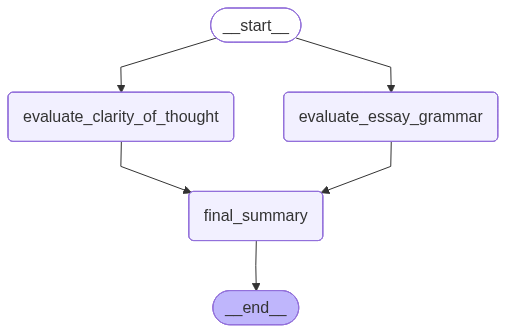

In [87]:
graph = StateGraph(EssayState)

graph.add_node("evaluate_essay_grammar", evaluate_essay_grammar)
graph.add_node("evaluate_clarity_of_thought", evaluate_clarity_of_thought)
graph.add_node("final_summary", final_summary)

graph.add_edge(START, "evaluate_essay_grammar")
graph.add_edge(START, "evaluate_clarity_of_thought")

graph.add_edge("evaluate_essay_grammar", "final_summary")
graph.add_edge("evaluate_clarity_of_thought", "final_summary")

graph.add_edge("final_summary", END)

workflow = graph.compile()
workflow

In [88]:
input_state = {
    "essay": """
        The quick brown fox jumps over the lazy dog. IT is growing rapidly. I want to build a house. 
        The dog was not happy about it, and barked loudly. However, the fox was too quick and escaped without any trouble.
    """
}

result = workflow.invoke(input_state)

In [89]:
print(result)

{'essay': '\n        The quick brown fox jumps over the lazy dog. IT is growing rapidly. I want to build a house. \n        The dog was not happy about it, and barked loudly. However, the fox was too quick and escaped without any trouble.\n    ', 'grammar_score': 7, 'grammar_feedback': 'Overall, the essay demonstrates good grammatical quality, but there are a few areas that could use improvement. Here\'s a breakdown based on the criteria provided:\n\n1. **Sentence Structure**: The sentences are clear and complete, but they lack variety. Most sentences follow a simple structure, which could be improved by combining some sentences.\n   - Example for variety: "The quick brown fox jumps over the lazy dog, and as it does, it grows rapidly in confidence."\n\n2. **Punctuation**: Punctuation is mostly correct, but there is an issue with the capitalization of \'IT\' in the second sentence, which should be \'It\'. Also, a comma before "and barked loudly" would enhance clarity: "the dog was not h

In [90]:
print(json.dumps(result, indent=2))

{
  "essay": "\n        The quick brown fox jumps over the lazy dog. IT is growing rapidly. I want to build a house. \n        The dog was not happy about it, and barked loudly. However, the fox was too quick and escaped without any trouble.\n    ",
  "grammar_score": 7,
  "grammar_feedback": "Overall, the essay demonstrates good grammatical quality, but there are a few areas that could use improvement. Here's a breakdown based on the criteria provided:\n\n1. **Sentence Structure**: The sentences are clear and complete, but they lack variety. Most sentences follow a simple structure, which could be improved by combining some sentences.\n   - Example for variety: \"The quick brown fox jumps over the lazy dog, and as it does, it grows rapidly in confidence.\"\n\n2. **Punctuation**: Punctuation is mostly correct, but there is an issue with the capitalization of 'IT' in the second sentence, which should be 'It'. Also, a comma before \"and barked loudly\" would enhance clarity: \"the dog wa